In [ ]:
import numpy as np
from rcpgenerator import Packing

## Monodisperse

In [11]:
packing = Packing(
    phi = 0.08, # Initial particle volume fraction
    N = 200, # Number of particles
    Ndim = 3, # Number of dimensions
    box = [1.0,1.0,1.0], # Box size
    walls = [0,0,0], # 0=periodic, 1=hard wall
    dist = {"type": "mono", "d": 1.0}, # Particle size distribution
    neighbor_max=0, # preallocated capacity for each particle's neighbor list (0=auto)
    seed=123, # Random seed for reproducibility
)

In [12]:
result = packing.pack()
print("final packing fraction:", packing.phi_final)
print("completed steps:", packing.steps)

final packing fraction: 0.6259430088586245
completed steps: 15555


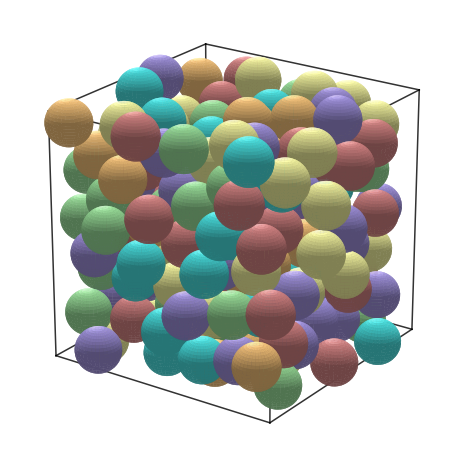

In [13]:
packing.show_packing(figsize=(4,4))

In [14]:
positions = np.asarray(packing.positions)   # (N, Ndim)
diameters = np.asarray(packing.diameters)   # (N,)
radii = diameters / 2.0

box_str = "x".join(f"{L:g}" for L in packing.box)  # e.g. "1x1x1"

data = np.column_stack([positions, radii])
np.savetxt(
    f"packing_mono_box_{box_str}_config.txt",
    data,
    header=f"x y z radius  (N={packing.N}, box={packing.box})",
)

## Uniformly distributed

In [15]:
packing_f = Packing(
    phi = 0.08, # Initial particle volume fraction
    N = 200, # Number of particles
    Ndim = 3, # Number of dimensions
    box = [1.0,1.0,1.0], # Box size
    walls = [0,0,0], # 0=periodic, 1=hard wall
    dist = {"type": "flat", "d_min": 0.5, "d_max": 1.5}, # Particle size distribution
    neighbor_max=0, # preallocated capacity for each particle's neighbor list (0=auto)
    seed=123, # Random seed for reproducibility
)

In [16]:
resultf = packing_f.pack()
print("final packing fraction:", packing_f.phi_final)
print("completed steps:", packing.steps)

final packing fraction: 0.6451091840618883
completed steps: 15555


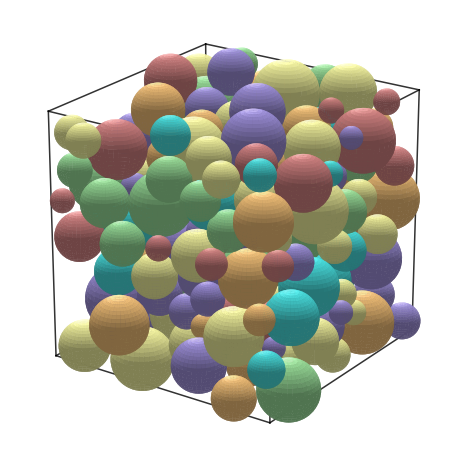

In [17]:
packing_f.show_packing(figsize=(4,4))

In [18]:
positions = np.asarray(packing_f.positions)   # (N, Ndim)
diameters = np.asarray(packing_f.diameters)   # (N,)
radii = diameters / 2.0

box_str = "x".join(f"{L:g}" for L in packing_f.box)  # e.g. "1x1x1"

data = np.column_stack([positions, radii])
np.savetxt(
    f"packing_uniform_box_{box_str}_config.txt",
    data,
    header=f"x y z radius  (N={packing_f.N}, box={packing_f.box})",
)